# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation

**Members:** Tanya Chhabra, Abhi Jindal, Daaksha B. Arun and Mahesh Wadhokar


## 1: Installing Dependencies

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.decomposition import PCA

import warnings
import logging
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger('jupyter_client').setLevel(logging.ERROR)

In [51]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2: Loading Dataset

In [52]:
primary_data = pd.read_csv('/content/drive/MyDrive/ML Project /updated Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

primary_data.head()

,ï»¿Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,GONAL-f,"Anovulation; Reproductive Techniques, Assiste...",follitropin alfa,follitropin alfa,EMEA/H/C/000071,no,Authorised,G03GA05,no,...,NaN,NaN,21/07/2022,25.0,", \tAnovulation (including polycystic ovarian ...",NaN,NaN,43167,44721,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Taxotere,"Head and Neck Neoplasms; Carcinoma, Non-Small...",docetaxel,docetaxel,EMEA/H/C/000073,no,Authorised,L01CD02,no,...,NaN,35040,44389,49.0,Breast cancerTaxotere in combination with doxo...,NaN,NaN,43102,14/12/2021,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Betaferon,Multiple Sclerosis,interferon beta-1b,interferon beta-1b,EMEA/H/C/000081,no,Authorised,L03AB08,no,...,NaN,35040,44785,35.0,Betaferon is indicated for the treatment ofpat...,NaN,NaN,28/07/2017,45261,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,CellCept,Graft Rejection,mycophenolate mofetil,mycophenolate mofetil,EMEA/H/C/000082,no,Authorised,L04AA06,no,...,NaN,NaN,16/02/2022,37.0,CellCept is indicated in combination with cicl...,NaN,NaN,43351,44595,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Fareston,Breast Neoplasms,toremifene,toremifene,EMEA/H/C/000091,no,Authorised,L02BA02,no,...,NaN,17/10/1995,24/11/2021,24.0,First line hormone treatment of hormone-depend...,NaN,NaN,26/07/2018,44267,https://www.ema.europa.eu/en/medicines/human/E...


# 3. Data Cleaning

In [53]:
print(f"Primary Data Shape: {primary_data.shape}")

Primary Data Shape: (1988, 30)


In [54]:
primary_data.nunique()

,0
ï»¿Category,2
Medicine name,1976
Therapeutic area,669
International non-proprietary name (INN) / common name,1261
Active substance,1345
Product number,1988
Patient safety,2
Authorisation status,3
ATC code,893
Additional monitoring,2


In [55]:
# checking missing values
missing_values = primary_data.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Therapeutic area                                           285
International non-proprietary name (INN) / common name       4
Active substance                                             1
Authorisation status                                         1
ATC code                                                   307
Marketing authorisation date                                60
Date of refusal of marketing authorisation                1913
Marketing authorisation holder/company name                  4
Human pharmacotherapeutic group                            311
Vet pharmacotherapeutic group                             1711
Date of opinion                                            779
Decision date                                               45
Revision number                                             96
Condition / indication                                      12
Species                                                   1709
ATCvet code                 

In [56]:
print(primary_data.columns.tolist())

['ï»¿Category', 'Medicine name', 'Therapeutic area', 'International non-proprietary name (INN) / common name', 'Active substance', 'Product number', 'Patient safety', 'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic', 'Biosimilar', 'Conditional approval', 'Exceptional circumstances', 'Accelerated assessment', 'Orphan medicine', 'Marketing authorisation date', 'Date of refusal of marketing authorisation', 'Marketing authorisation holder/company name', 'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group', 'Date of opinion', 'Decision date', 'Revision number', 'Condition / indication', 'Species', 'ATCvet code', 'First published', 'Revision date', 'URL']


In [57]:
# Removing the BOM prefix
primary_data.columns = primary_data.columns.str.replace('ï»¿', '').str.strip()
print(primary_data.columns.tolist())

['Category', 'Medicine name', 'Therapeutic area', 'International non-proprietary name (INN) / common name', 'Active substance', 'Product number', 'Patient safety', 'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic', 'Biosimilar', 'Conditional approval', 'Exceptional circumstances', 'Accelerated assessment', 'Orphan medicine', 'Marketing authorisation date', 'Date of refusal of marketing authorisation', 'Marketing authorisation holder/company name', 'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group', 'Date of opinion', 'Decision date', 'Revision number', 'Condition / indication', 'Species', 'ATCvet code', 'First published', 'Revision date', 'URL']


In [58]:
primary_data = primary_data.dropna(subset=['Marketing authorisation holder/company name'])
primary_data = primary_data.dropna(subset=['Authorisation status'])
primary_data = primary_data.dropna(subset=['Generic'])
primary_data = primary_data.dropna(subset=['Revision number'])

print(primary_data[['Marketing authorisation holder/company name', 'Authorisation status', 'Generic', 'Revision number']].isnull().sum())


Marketing authorisation holder/company name    0
Authorisation status                           0
Generic                                        0
Revision number                                0
dtype: int64


In [59]:
#cleaning columns and dropping missing values
primary_data.columns = primary_data.columns.str.replace('ï»¿', '').str.strip()
primary_data = primary_data.dropna(subset=['Marketing authorisation holder/company name', 'Authorisation status', 'Generic'])

#standardizing the 'generic' column to business labels
primary_data['Generic_Label'] = primary_data['Generic'].astype(str).str.strip().str.lower().map({'yes': 'Generic', 'no': 'Branded'})

#building transaction baskets
primary_data['basket'] = (primary_data['Marketing authorisation holder/company name'].astype(str) + ',' + primary_data['Authorisation status'].astype(str) + ',' +
    primary_data['Generic_Label'])
data = [row.split(',') for row in primary_data['basket']]
print(f"Baskets created: {len(data)}")

Baskets created: 1889


# 4. Feature Engineering

In [60]:
from mlxtend.preprocessing import TransactionEncoder

#transforming text lists into a binary matrix
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Matrix Shape: {df_encoded.shape}")
df_encoded.head()

Matrix Shape: (1889, 607)


,B.V.,Chem.-Pharm. Fabrik GmbH..,Galapagos NV,Institut fÃ¼r biomedizinische Analytik NMR-Imaging GmbH,Novo mesto,Novo mestoÂ,S.A.,S.A.U.,S.L.,S.L.U.,...,bene-Arzneimittel GmbH,betapharm Arzneimittel GmbH,bluebird bio (Netherlands) B.V.,medac Gesellschaft fÃ¼r klinische SpezialprÃ¤parate mbH,ratiopharm GmbH,sanofi-aventis,sanofi-aventis Deutschland GmbH,sanofi-aventis groupeÂ,uniQure biopharma B.V.Â,zr pharma& GmbH
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [61]:
#standardizing generic and branded labels
primary_data['Generic_Label'] = primary_data['Generic'].astype(str).str.strip().str.lower().map({'yes': 'Generic', 'no': 'Branded'})

#grouping features
primary_data['basket'] = (primary_data['Marketing authorisation holder/company name'].astype(str) + ',' + primary_data['Authorisation status'].astype(str) + ',' +
    primary_data['Generic_Label'])
data_list = [row.split(',') for row in primary_data['basket']]
print(f"Data prepared: {len(data_list)} records found.")

Data prepared: 1889 records found.


In [62]:
from mlxtend.preprocessing import TransactionEncoder

# creating a binary matrix
te = TransactionEncoder()
te_ary = te.fit(data_list).transform(data_list)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Dimensions: {df_encoded.shape[1]} (Companies & Statuses)")

Dimensions: 607 (Companies & Statuses)


## 5. Regulatory Logic (ARM)

In [63]:
#lift and support
frequent_itemsets = apriori(df_encoded, min_support=0.002, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5) # Raised threshold to 1.5

#sorting to highlight the strongest strategic links
rules = rules.sort_values(by='lift', ascending=False)
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

,antecedents,consequents,support,confidence,lift
606,( k.s.),"(Authorised, Zentiva, Generic)",0.002118,1.0,472.250000
605,(Zentiva),"(Authorised, k.s., Generic)",0.002118,1.0,472.250000
604,"( k.s., Generic)","(Authorised, Zentiva)",0.002118,1.0,472.250000
602,"(Authorised, k.s.)","(Zentiva, Generic)",0.002118,1.0,472.250000
24,(Zentiva),( k.s.),0.002118,1.0,472.250000
25,( k.s.),(Zentiva),0.002118,1.0,472.250000
599,"(Authorised, Zentiva)","( k.s., Generic)",0.002118,1.0,472.250000
601,"(Zentiva, Generic)","(Authorised, k.s.)",0.002118,1.0,472.250000
597,"(Authorised, Zentiva, Generic)",( k.s.),0.002118,1.0,472.250000
598,"(Authorised, k.s., Generic)",(Zentiva),0.002118,1.0,472.250000


# PCA

In [64]:
!pip install psynlig

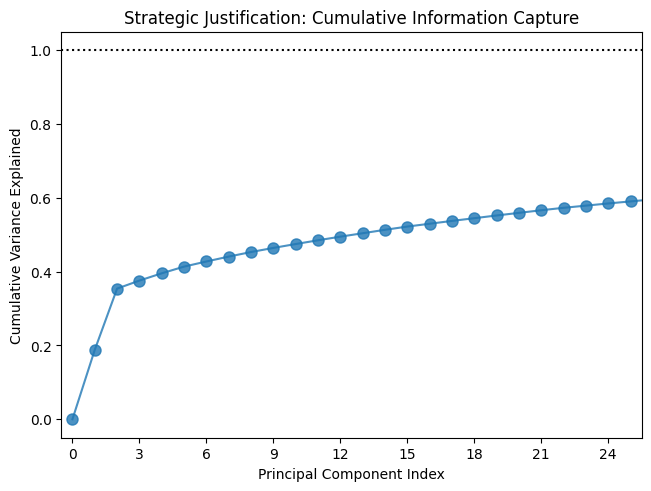

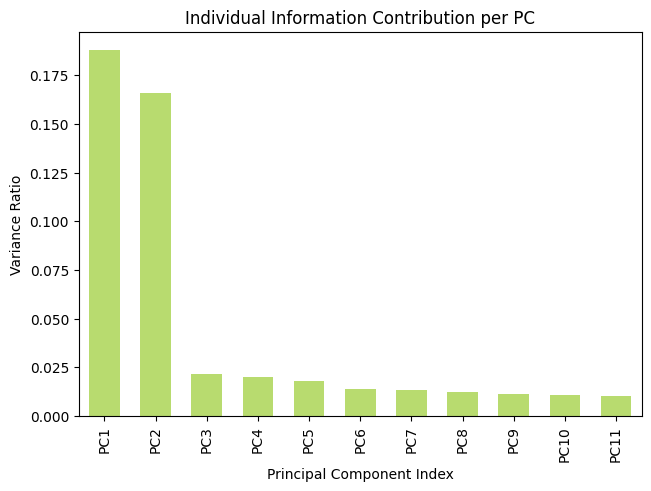

In [65]:
#cumulative plot showing the information ceiling
_, ax1 = pca_explained_variance(pca_full, marker='o', markersize=8, alpha=0.8)

ax1.set_title('Strategic Justification: Cumulative Information Capture')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Cumulative Variance Explained')

#since there are 600+ PCs, we zoom into the first 25 to observe the elbow
ax1.set_xlim(-0.5, 25.5)
plt.show()

#creating bar plot reflecting the information contribuition per PC
pca_explained_variance_bar(pca_full, width=0.6, alpha=0.7, color='yellowgreen')
plt.title('Individual Information Contribution per PC')
plt.xlabel('Principal Component Index')
plt.ylabel('Variance Ratio')

#looking at the first few to identify the dominant signals
plt.xlim(-0.5, 10.5)
plt.show()

In [66]:
#from the elbow and the scree plot, n=2 looks justified
pca_final = PCA(n_components=2)
pca_features = pca_final.fit_transform(df_encoded)

# summary dataframe for the map
df_visual = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
df_visual['Market_Category'] = primary_data['Generic_Label'].values
df_visual['Company'] = primary_data['Marketing authorisation holder/company name'].values

print(f"Final Setup Complete.Explained Variance: {sum(pca_final.explained_variance_ratio_):.2%}")

Final Setup Complete.Explained Variance: 35.40%


In [68]:
import plotly.express as px

# visualization of clusters
fig = px.scatter(df_visual, x='PC1', y='PC2', color='Market_Category', color_discrete_map=color_map,hover_data=['Company'],title="Pharma Market Structural Regimes (PCA Representation)")
color_map = {'Branded': '#006400', 'Generic': '#0000FF'}
fig.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='White')))
fig.update_layout( plot_bgcolor='white', xaxis=dict(showgrid=True, gridcolor='lightgrey'), yaxis=dict(showgrid=True, gridcolor='lightgrey'))
fig.show()